### Project description
- Load the titanic dataset
- handle missing values (drop or fill them)
- Encode categorical columns (embarked, sex)
- Train logistic regre4ssio model to predict suvival
- Print classification report and plot confusion matric
- also try KNN and compare the two

In [66]:
#lets load the titanic dataset from seaborn and do EDA  to understand the data better
import seaborn as sns
titanic = sns.load_dataset('titanic')

#lets view how the data looks like
print(f"First 5 rows of the dataset:\n{titanic.head()}")

print(f"\n\nNumber of rows and columns: {titanic.shape}")

print(f"\n\nSummary statistics:\n{titanic.describe()}")

First 5 rows of the dataset:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


Number of rows and columns: (891, 15)


Summary statistics:
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000

In [67]:
#lets check null values in the dataset
print(f"Null values in the dataset:\n{titanic.isnull().sum()}")

Null values in the dataset:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [68]:
#we will drop deck and embark_town because they don't have much relevance to the target variable.
#age has several null values, so let's fill them with the median age since it is important
titanic['age'] = titanic['age'].fillna(titanic['age'].median())

#lets check missing values again
print(f"Missing values after filling age:\n{titanic.isnull().sum()}")

Missing values after filling age:
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [ ]:
#lets drop the columns that are not useful ie. embark_town, alive,  fare, deck. We will also drop class because it is redudant wth pclass and who to sex
titanic.drop(['embark_town', 'alive', 'who', 'fare', 'deck', 'class'], axis=1, inplace=True)
print(f"Columns after dropping:\n{titanic.columns}")

Columns after dropping:
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked',
       'adult_male', 'alone'],
      dtype='str')


In [70]:
# lets change the columns with categorical data to numerical ie. sex, adult_male, alone
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic['adult_male'] = titanic['adult_male'].astype(int)
titanic['alone'] = titanic['alone'].astype(int)

#print first 5 rows to see how it looks like after encoding
print(f"First 5 rows after encoding:\n{titanic.head()}")

First 5 rows after encoding:
   survived  pclass  sex   age  sibsp  parch embarked  adult_male  alone
0         0       3    0  22.0      1      0        S           1      0
1         1       1    1  38.0      1      0        C           0      0
2         1       3    1  26.0      0      0        S           0      1
3         1       1    1  35.0      1      0        S           0      0
4         0       3    0  35.0      0      0        S           1      1


In [ ]:
#lets split data into features and target variable
#y will be survived and x will be the rest of the columns
y = titanic['survived']
X = titanic[['pclass', 'sex', 'age', 'sibsp', 'parch', 'adult_male', 'alone']]

#lets split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [74]:
#now lets choose our model. We will use logisitc regression

from sklearn.linear_model import LogisticRegression

#lets create an instance of the model
titanic_model = LogisticRegression()

#fit the model to the training data
titanic_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [75]:
#lets make predictions on the test set
y_pred = titanic_model.predict(X_test)

#we will evaluate the model using accuracy score
from sklearn.metrics import accuracy_score  
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of the model: {accuracy:.2f}")

Accuracy of the model: 0.84


<Axes: >

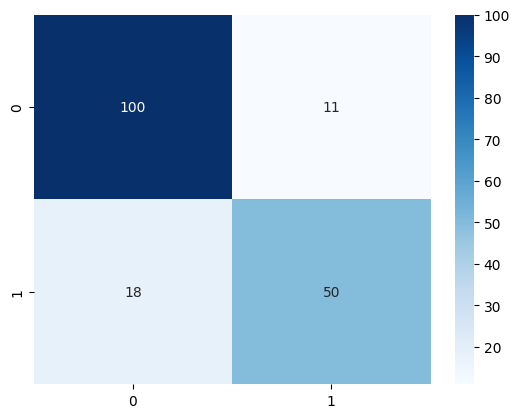

In [76]:
#lets plot the confusion matrix to see how well the model is performing
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
c_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(c_matrix, annot=True, fmt='d', cmap='Blues')

In [78]:
#lets print the classification report
from sklearn.metrics import classification_report
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       111
           1       0.82      0.74      0.78        68

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.84      0.84      0.84       179

